# UQTS-2026: Alpha Discovery Lab
## Phase 1: Signal vs. Fluid Framework

This notebook demonstrates the foundational components of the **UQTS-2026** research lab:
1. **Bi-temporal Data Engine**: Point-in-Time (PIT) consistency.
2. **Fractional Differentiation**: Stationarity with memory preservation.
3. **Wavelet Spectrograms**: Multi-resolution spectral analysis.
4. **Residualized Alpha**: Idiosyncratic target labeling (Multi-Ticker).
5. **Alpha Ranker**: RankNet LTR model for cross-sectional scoring.

In [18]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datetime import datetime, timedelta

from research_lab.data_engine import DataEngine
from research_lab.alpha_core import FractionalDifferencer, WaveletFeatureGenerator
from research_lab.alpha_labeler import AlphaLabeler
from research_lab.alpha_ranker import RankNet
from research_lab.alpha_universe import AlphaUniverse

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]

### 1. Data Ingestion (Bi-temporal PIT)
We generate synthetic data with a 'Knowledge Time' delay to verify zero look-ahead bias.

In [19]:
engine = DataEngine()
tickers = ['AAPL', 'MSFT', 'GOOG', 'SPY']
engine.generate_synthetic_pit_data(tickers, days=500)

# Fetch a PIT view as of midway through the period
as_of_date = datetime(2020, 1, 1) + timedelta(days=250)
pit_view = pd.concat([engine.get_pit_view(t, as_of_date) for t in tickers])

print(f"Data points known for universe as of {as_of_date}: {len(pit_view)}")
pit_view.head()

Data points known for universe as of 2020-09-07 00:00:00: 1000


,ticker,event_time,knowledge_time,open,high,low,close,volume,is_correction
0,AAPL,2020-01-01,2020-01-01 16:00:00,99.491747,101.501681,98.486780,100.496714,77820,NaN
1,AAPL,2020-01-02,2020-01-02 16:00:00,99.354185,101.361341,98.350608,100.357763,83386,NaN
2,AAPL,2020-01-03,2020-01-03 16:00:00,97.356210,99.323002,96.372814,98.339606,61263,NaN
3,AAPL,2020-01-04,2020-01-04 16:00:00,96.876435,98.833535,95.897885,97.854985,68221,NaN
4,AAPL,2020-01-05,2020-01-05 16:00:00,97.102249,99.063911,96.121418,98.083080,68969,NaN


### 2. Fractional Differentiation ($d=0.4$)
Stationarizing the series while preserving long-term memory.

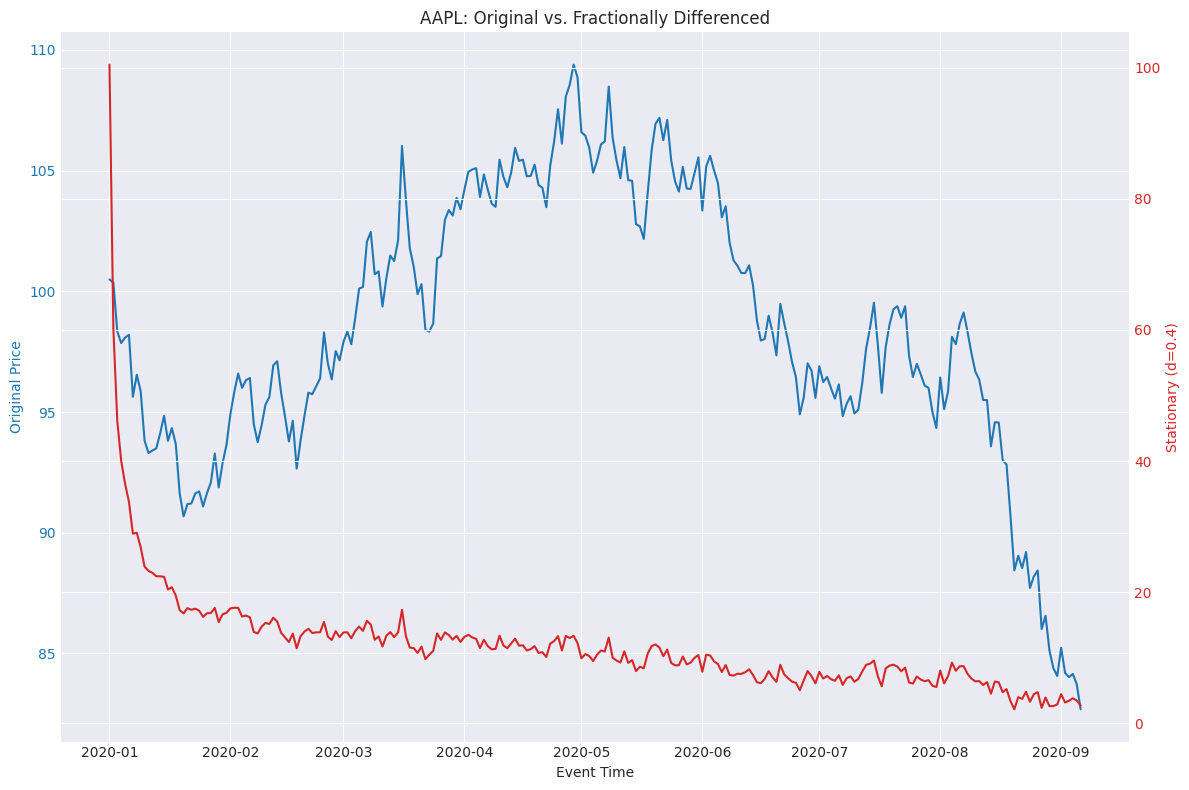

In [20]:
fd = FractionalDifferencer(d=0.4)
aapl_view = engine.get_pit_view('AAPL', as_of_date)
aapl_stationary = fd.transform(aapl_view['close'])

fig, ax1 = plt.subplots()

ax1.set_xlabel('Event Time')
ax1.set_ylabel('Original Price', color='tab:blue')
ax1.plot(aapl_view['event_time'], aapl_view['close'], color='tab:blue', label='Original')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Stationary (d=0.4)', color='tab:red')
ax2.plot(aapl_view['event_time'], aapl_stationary, color='tab:red', label='Stationary')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('AAPL: Original vs. Fractionally Differenced')
fig.tight_layout()
plt.show()

### 3. Wavelet Spectrogram (Morlet)
Analyzing the signal across dyadic scales to detect regimes.

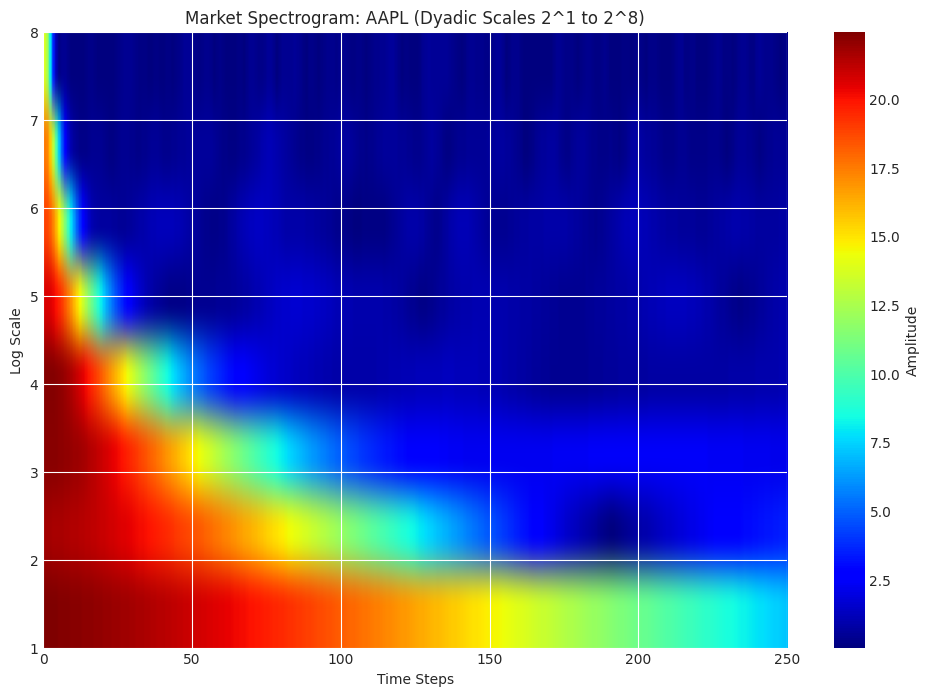

In [21]:
wfg = WaveletFeatureGenerator()
spectrogram = wfg.generate(aapl_stationary)

plt.imshow(spectrogram, aspect='auto', cmap='jet', extent=[0, len(aapl_stationary), 1, 8])
plt.colorbar(label='Amplitude')
plt.title('Market Spectrogram: AAPL (Dyadic Scales 2^1 to 2^8)')
plt.ylabel('Log Scale')
plt.xlabel('Time Steps')
plt.show()

### 4. Multi-Ticker Residualized Alpha & Z-Scoring
Full pipeline: Calculate Returns -> Residualize vs SPY -> Cross-sectional Z-Score.

Final Multi-Ticker RankNet Target Labels (Z-Scores):


,AAPL,GOOG,MSFT
event_time,,,
2020-09-02,NaN,NaN,NaN
2020-09-03,NaN,NaN,NaN
2020-09-04,NaN,NaN,NaN
2020-09-05,NaN,NaN,NaN
2020-09-06,NaN,NaN,NaN



Average Cross-sectional Mean: 1.0616e-17 (Should be ~0)


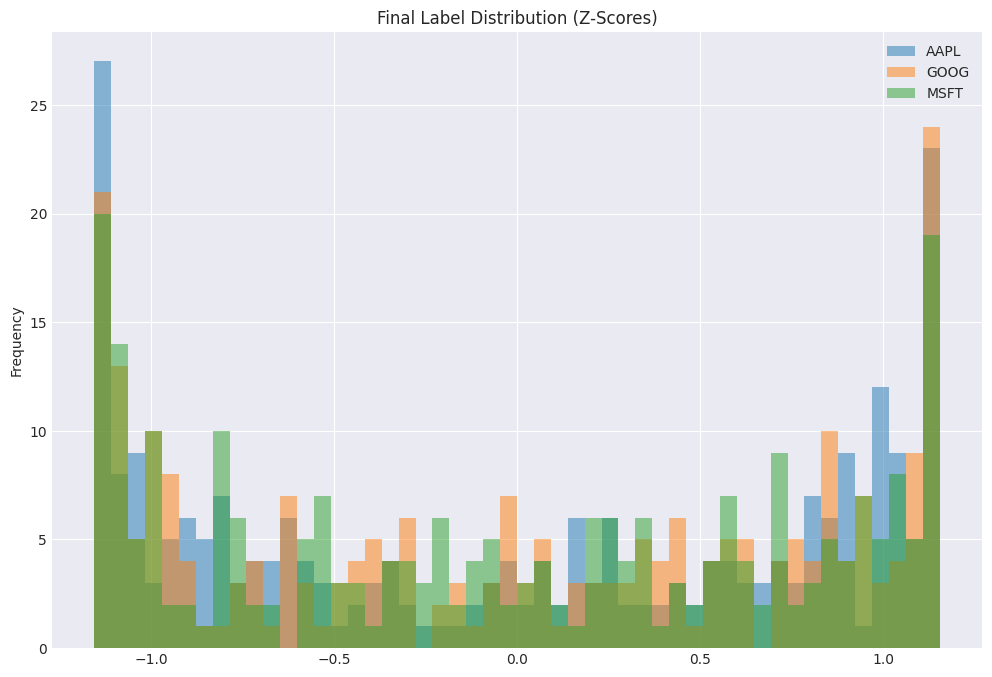

In [22]:
labeler = AlphaLabeler()

# 1. Generate forward returns (horizon=5 for demo)
returns_df = labeler.generate_labels(pit_view, horizon=5)

# 2. Residualize Universe against SPY
market_proxy = returns_df['SPY']
asset_returns = returns_df.drop(columns=['SPY'])
residuals = labeler.residualize_universe(asset_returns, market_proxy)

# 3. Apply Cross-sectional Z-Score
final_labels = labeler.apply_z_score(residuals)

print("Final Multi-Ticker RankNet Target Labels (Z-Scores):")
display(final_labels.tail())

# Verify zero mean per row (cross-section)
row_means = final_labels.mean(axis=1)
print(f"\nAverage Cross-sectional Mean: {row_means.mean():.4e} (Should be ~0)")

# Plot Target Distribution
final_labels.plot(kind='hist', bins=50, alpha=0.5)
plt.title('Final Label Distribution (Z-Scores)')
plt.show()

### 5. Alpha Ranker (RankNet LTR)
Inference with the RankNet model.

In [23]:
# Input features: 8 wavelet scales
model = RankNet(input_dim=8)
model.eval()

# Sample input (spectrogram at last timestep)
sample_input = torch.tensor(spectrogram[:, -1]).unsqueeze(0).float()
with torch.no_grad():
    score = model(sample_input)

print(f"RankNet Output Score for AAPL (Latest): {score.item():.4f}")

RankNet Output Score for AAPL (Latest): 0.2055


### 6. The AlphaUniverse Deep Module (Leverage)\n
We can now achieve the entire data preparation pipeline (Fetch -> Transform -> Label -> Align) in a single call.

In [24]:
universe = AlphaUniverse(engine)
dataset = universe.get_aligned_dataset(
    tickers=['AAPL', 'MSFT', 'GOOG', 'SPY'],
    as_of_date=as_of_date,
    horizon=5,
    d_param=0.4
)

print(f"Aligned Dataset Shape: {dataset.shape}")
display(dataset.head())

# Verify cross-sectional Z-score property on the new dataset\n
daily_mean = dataset.groupby('event_time')['label'].mean()
print(f"Average Daily Mean of Labels: {daily_mean.mean():.4e}")

Aligned Dataset Shape: (735, 11)


,event_time,scale_0,scale_1,scale_2,scale_3,scale_4,scale_5,scale_6,scale_7,ticker,label
0,2020-01-01,13.820449,17.582401,18.896216,20.696219,22.345703,22.270257,21.713666,22.454224,AAPL,-0.685874
500,2020-01-01,13.571427,16.627106,18.956609,20.231038,20.858811,24.189409,24.472239,24.558215,GOOG,-0.461540
250,2020-01-01,13.878793,17.505370,18.805138,20.479694,22.422718,24.483060,26.599359,28.283104,MSFT,1.147414
1,2020-01-02,12.417706,17.241649,18.736597,20.669268,22.364046,22.267840,21.696063,22.436656,AAPL,-0.911706
501,2020-01-02,12.218358,16.138508,18.859671,20.209560,20.834315,24.215779,24.467931,24.539366,GOOG,-0.157820


Average Daily Mean of Labels: 1.1673e-17
